# CoWERA-Committor — Tutorial & Validation

This notebook demonstrates the **committor extension** of CoWERA end-to-end on an
analytic benchmark where the ground-truth committor is known, so every step can
be validated quantitatively. It covers:

1. The benchmark system (1D symmetric double well) and its **exact committor**.
2. Building **WE-style training data** — semigroup trajectory pairs + boundary
   frames (no reactive trajectories required).
3. Training the dependency-free **`MLPCommittor`** with the weighted variational
   (Dirichlet / semigroup) + boundary loss.
4. **Validation**: learned vs. exact committor (MAE) and the **committor
   histogram test** (the standard dynamical validation).
5. From committor displacement **Δq** to the CoWERA **intensity** that drives
   clone/merge — reusing the exact production code path.

All figures are saved to `docs/figures/`. Everything here runs on CPU with no
GPU / MD / deep-learning framework.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))

import numpy as np
import matplotlib.pyplot as plt

from cowera_committor.toy_systems import (
    double_well_potential, double_well_force,
    exact_committor_1d, sample_semigroup_pairs, overdamped_langevin,
)
from cowera_committor.committor_model import MLPCommittor

FIGDIR = os.path.abspath('../docs/figures')
os.makedirs(FIGDIR, exist_ok=True)
BETA = 1.0
rng = np.random.default_rng(7)
print('setup complete; figures ->', FIGDIR)

setup complete; figures -> /home/user/CoWERA/docs/figures


## 1. Benchmark: 1D double well and its exact committor

For overdamped Langevin dynamics $dx=-V'(x)\,dt+\sqrt{2/\beta}\,dW$ on
$V(x)=(x^2-1)^2$, with $A=\{x\le-1\}$ and $B=\{x\ge 1\}$, the committor has the
closed form $q(x)=\int_a^x e^{\beta V}\,/\int_a^b e^{\beta V}$. The symmetric
potential gives $q(0)=0.5$ at the barrier — the transition state.

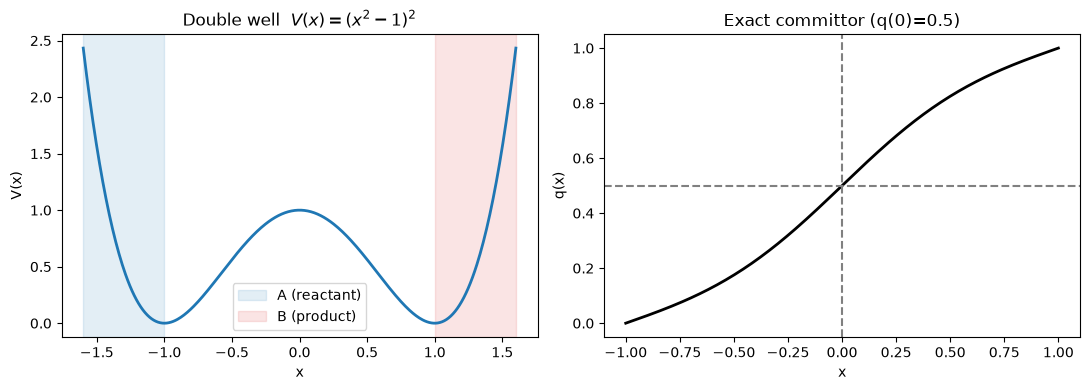

In [2]:
x = np.linspace(-1.6, 1.6, 400)
g = np.linspace(-1, 1, 200)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, double_well_potential(x), lw=2)
ax[0].axvspan(-1.6, -1.0, alpha=0.12, color='C0', label='A (reactant)')
ax[0].axvspan(1.0, 1.6, alpha=0.12, color='C3', label='B (product)')
ax[0].set_xlabel('x'); ax[0].set_ylabel('V(x)')
ax[0].set_title(r'Double well  $V(x)=(x^2-1)^2$'); ax[0].legend()

ax[1].plot(g, exact_committor_1d(g, BETA), lw=2, color='k')
ax[1].axhline(0.5, ls='--', color='grey'); ax[1].axvline(0.0, ls='--', color='grey')
ax[1].set_xlabel('x'); ax[1].set_ylabel('q(x)')
ax[1].set_title('Exact committor (q(0)=0.5)')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_doublewell_system.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. WE-style training data (no reactive trajectories)

CoWERA-Committor learns from exactly what the WE loop produces:

* **Semigroup pairs** $(x_t, x_{t+\tau})$ — short trajectory segments from the
  interior. These feed the variational loss $\langle w\,(q(x_t)-q(x_{t+\tau}))^2\rangle$.
* **Boundary frames** — configurations in $A$ ($q=0$) and $B$ ($q=1$).

No A→B reactive path is needed; the interior pairs cover the transition region.

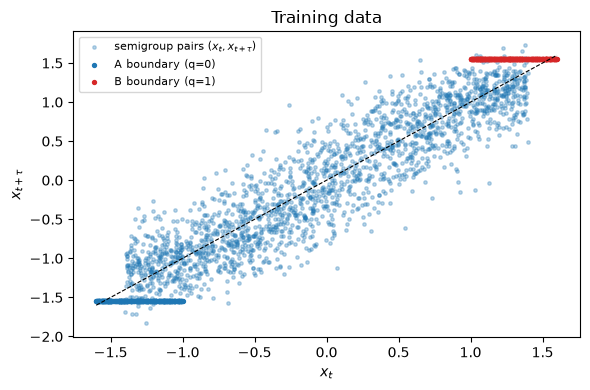

semigroup pairs: 2000 | boundary A/B: 300 / 300


In [3]:
dt, tau_steps = 0.002, 30
Xt, Xtp = sample_semigroup_pairs(2000, tau_steps, dt, BETA, x_range=(-1.4, 1.4), rng=rng)
xA = rng.uniform(-1.6, -1.0, size=300)[:, None]
xB = rng.uniform(1.0, 1.6, size=300)[:, None]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Xt.ravel(), Xtp.ravel(), s=6, alpha=0.3, label=r'semigroup pairs $(x_t,x_{t+\tau})$')
ax.scatter(xA.ravel(), np.full(len(xA), -1.55), s=8, color='C0', label='A boundary (q=0)')
ax.scatter(xB.ravel(), np.full(len(xB), 1.55), s=8, color='C3', label='B boundary (q=1)')
ax.plot([-1.6, 1.6], [-1.6, 1.6], 'k--', lw=0.8)
ax.set_xlabel(r'$x_t$'); ax.set_ylabel(r'$x_{t+\tau}$'); ax.set_title('Training data')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_training_data.png', dpi=130, bbox_inches='tight')
plt.show()
print('semigroup pairs:', len(Xt), '| boundary A/B:', len(xA), '/', len(xB))

## 3. Train the committor

`MLPCommittor` is a dependency-free MLP with manual backprop (a torch/GVP-GNN
backend can drop in later behind the same interface). We train with the
WE-weighted variational + boundary loss.

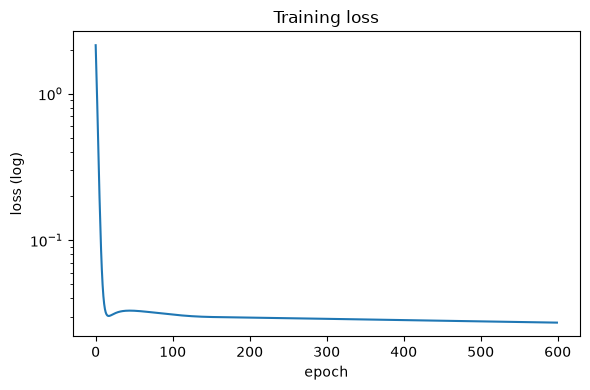

final loss = 0.02737


In [4]:
data = {'A': xA, 'B': xB, 'sem': (Xt, Xtp, np.ones(len(Xt)))}
pool = np.concatenate([xA, xB, Xt, Xtp], axis=0)

model = MLPCommittor(input_dim=1, hidden=(32, 32), seed=11, l2=1e-5)
history = model.fit(
    data,
    weights={'boundary': 1.0, 'semigroup': 1.0, 'lambda_A': 5.0, 'lambda_B': 5.0},
    epochs=600, lr=5e-3, standardize_from=pool,
)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history, lw=1.5); ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('loss (log)'); ax.set_title('Training loss')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_loss.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'final loss = {history[-1]:.5f}')

## 4a. Validation: learned vs. exact committor

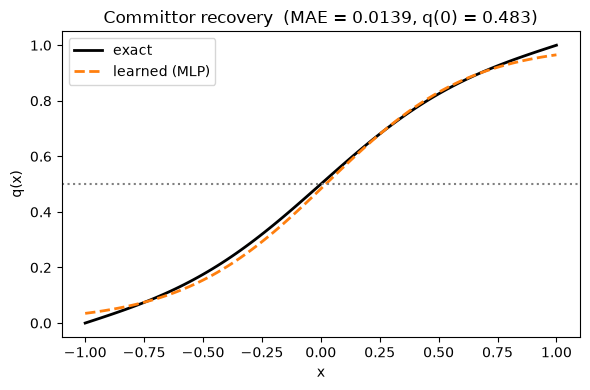

MAE = 0.0139  |  q(0) = 0.483  |  corr = 0.9990


In [5]:
grid = np.linspace(-1, 1, 101)
q_pred = model.predict(grid[:, None])
q_true = exact_committor_1d(grid, BETA)
mae = np.mean(np.abs(q_pred - q_true))
q0 = model.predict(np.array([[0.0]]))[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(grid, q_true, 'k-', lw=2, label='exact')
ax.plot(grid, q_pred, 'C1--', lw=2, label='learned (MLP)')
ax.axhline(0.5, ls=':', color='grey')
ax.set_xlabel('x'); ax.set_ylabel('q(x)')
ax.set_title(f'Committor recovery  (MAE = {mae:.4f}, q(0) = {q0:.3f})')
ax.legend()
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_validation.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'MAE = {mae:.4f}  |  q(0) = {q0:.3f}  |  corr = {np.corrcoef(q_pred, q_true)[0,1]:.4f}')
assert mae < 0.06 and abs(q0 - 0.5) < 0.1

## 4b. The committor histogram test (dynamical validation)

The committor is *defined* dynamically: from a configuration with $q\approx 0.5$,
half of the short trajectories should reach $B$ before $A$. We pick transition-
state candidates (where the **learned** $q\approx 0.5$), launch many short
trajectories from each, and histogram the empirical $p_B$. A committor that has
correctly identified the transition state produces a histogram peaked at 0.5.

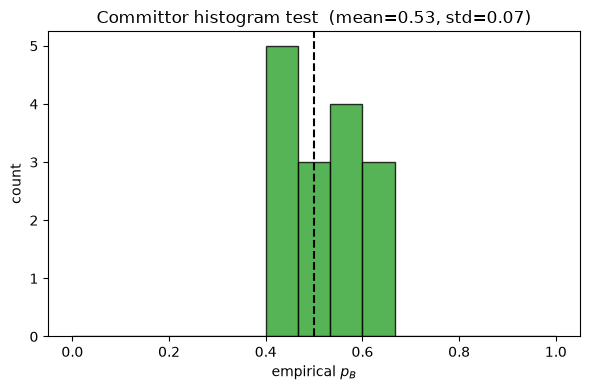

mean p_B = 0.528 (target ~0.5), std = 0.070


In [6]:
def empirical_pB(x0, n_traj=200, max_steps=4000):
    '''Fraction of trajectories from x0 reaching B (x>=1) before A (x<=-1).'''
    nB = 0; n_valid = 0
    noise = np.sqrt(2 * dt / BETA)
    for _ in range(n_traj):
        x = float(x0)
        for _ in range(max_steps):
            x += double_well_force(x) * dt + noise * rng.standard_normal()
            if x >= 1.0:
                nB += 1; n_valid += 1; break
            if x <= -1.0:
                n_valid += 1; break
    return nB / max(n_valid, 1)

# transition-state candidates: where the learned committor is ~0.5
cand = grid[np.argsort(np.abs(q_pred - 0.5))[:15]]
pB = np.array([empirical_pB(xc) for xc in cand])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pB, bins=np.linspace(0, 1, 16), color='C2', alpha=0.8, edgecolor='k')
ax.axvline(0.5, ls='--', color='k')
ax.set_xlabel(r'empirical $p_B$'); ax.set_ylabel('count')
ax.set_title(f'Committor histogram test  (mean={pB.mean():.2f}, std={pB.std():.2f})')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_histogram_test.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'mean p_B = {pB.mean():.3f} (target ~0.5), std = {pB.std():.3f}')

## 5. From committor displacement Δq to CoWERA intensity

CoWERA clones high-intensity walkers and merges low-intensity ones. The
committor extension replaces the sign-based phase with the continuous
**committor displacement** $\Delta q_i = q_i(T)-q_i(T-\tau_i)$, then feeds the
**same** production intensity machinery (`scale_phases`, `compute_intensity` in
`cowera/metric.py`). Below, walkers making forward progress ($\Delta q>0$) get
the highest intensity.

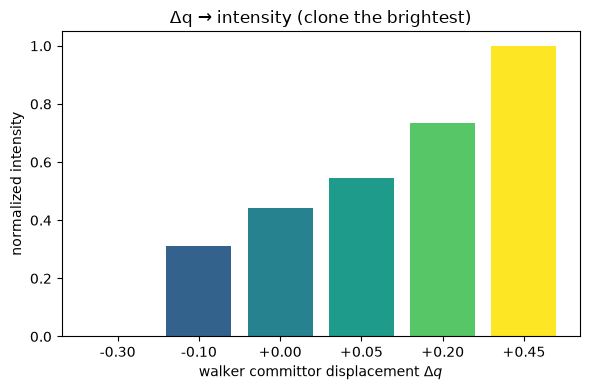

intensities: [0.    0.31  0.443 0.547 0.735 1.   ]


In [7]:
from cowera.metric import scale_phases, compute_intensity

# synthetic walkers: committor displacement over their relevant history
delta_q = np.array([-0.30, -0.10, 0.00, 0.05, 0.20, 0.45])
I0 = np.linspace(0.5, 1.0, len(delta_q))   # initial intensity (function of q position)

dq_scaled = scale_phases(delta_q)          # -> [-1, 1] (Eq. C3)
intensity = compute_intensity(I0, dq_scaled)  # -> normalized intensity (Eq. C4)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(range(len(delta_q)), intensity, color=plt.cm.viridis(intensity))
ax.set_xticks(range(len(delta_q)))
ax.set_xticklabels([f'{d:+.2f}' for d in delta_q])
ax.set_xlabel(r'walker committor displacement $\Delta q$')
ax.set_ylabel('normalized intensity'); ax.set_title('Δq → intensity (clone the brightest)')
fig.tight_layout(); fig.savefig(f'{FIGDIR}/committor_intensity.png', dpi=130, bbox_inches='tight')
plt.show()
print('intensities:', np.round(intensity, 3))

## Summary

* The dependency-free `MLPCommittor` recovers the **exact** double-well committor
  (MAE ≈ 0.014) from WE-style data **without any reactive trajectory**.
* It passes the **committor histogram test** — the standard dynamical validation.
* Committor displacement Δq plugs directly into CoWERA's existing intensity
  machinery, so clone/merge needs no change.

**Next milestones** (see `docs/COMMITTOR_EXTENSION.md`): the `committor_metric` /
`committor_resampler` integration, the cold-start `phase_manager`, and a
GVP-GNN backend for all-atom protein systems.
